In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment ready!")

Environment ready!


In [3]:
file_path = "../data/raw/online_retail_10_11.csv"

df = pd.read_csv(file_path)

print("Dataset loaded!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded!
Rows: 541910
Columns: 8


In [4]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541910 non-null  str    
 1   StockCode    541910 non-null  str    
 2   Description  540456 non-null  str    
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  str    
 5   UnitPrice    541910 non-null  float64
 6   CustomerID   406830 non-null  float64
 7   Country      541910 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:


df.duplicated().sum()

np.int64(5268)

In [9]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 5268


In [10]:
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate percentage:", round(duplicate_percentage, 2), "%")

Duplicate percentage: 0.97 %


In [11]:
negative_quantity = (df["Quantity"] < 0).sum()

print("Negative quantity rows:", negative_quantity)

Negative quantity rows: 10624


In [12]:
print(df[df["Quantity"] < 0][
    ["InvoiceNo", "StockCode", "Quantity", "UnitPrice"]
].head(10))

    InvoiceNo StockCode  Quantity  UnitPrice
141   C536379         D        -1      27.50
154   C536383    35004C        -1       4.65
235   C536391     22556       -12       1.65
236   C536391     21984       -24       0.29
237   C536391     21983       -24       0.29
238   C536391     21980       -24       0.29
239   C536391     21484       -12       3.45
240   C536391     22557       -12       1.65
241   C536391     22553       -24       1.65
937   C536506     22960        -6       4.25


In [13]:
print("Zero price rows:", (df["UnitPrice"] == 0).sum())
print("Negative price rows:", (df["UnitPrice"] < 0).sum())

Zero price rows: 2515
Negative price rows: 2


In [14]:
df["InvoiceDate"].head()

0    12/1/2010 8:26
1    12/1/2010 8:26
2    12/1/2010 8:26
3    12/1/2010 8:26
4    12/1/2010 8:26
Name: InvoiceDate, dtype: str

In [15]:
df.duplicated().sum()

np.int64(5268)

In [16]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [17]:
print("Zero price:", (df["UnitPrice"] == 0).sum())
print("Negative price:", (df["UnitPrice"] < 0).sum())

Zero price: 2515
Negative price: 2


In [18]:
df["InvoiceDate"].head()

0    12/1/2010 8:26
1    12/1/2010 8:26
2    12/1/2010 8:26
3    12/1/2010 8:26
4    12/1/2010 8:26
Name: InvoiceDate, dtype: str

In [19]:
clean_df = df.copy()

print("Original rows:", len(clean_df))

Original rows: 541910


In [20]:
clean_df = clean_df.drop_duplicates()

print("Rows after removing duplicates:", len(clean_df))

Rows after removing duplicates: 536642


In [21]:
clean_df["InvoiceDate"] = pd.to_datetime(
    clean_df["InvoiceDate"],
    format="%m/%d/%Y %H:%M"
)

print(clean_df["InvoiceDate"].dtype)

datetime64[us]


In [22]:
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]

clean_df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [23]:
clean_df["Revenue"].describe()

count    536642.000000
mean         18.123861
std         380.655908
min     -168469.600000
25%           3.750000
50%           9.870000
75%          17.400000
max      168469.600000
Name: Revenue, dtype: float64

In [24]:
clean_df["IsReturn"] = clean_df["Quantity"] < 0

In [25]:
clean_df["IsReturn"].value_counts()

IsReturn
False    526055
True      10587
Name: count, dtype: int64

In [26]:
sales_df = clean_df[
    (clean_df["Quantity"] > 0) &
    (clean_df["UnitPrice"] > 0)
].copy()

In [27]:
print("Clean sales rows:", len(sales_df))

Clean sales rows: 524879


In [28]:
sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsReturn
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False


In [29]:
print(clean_df.shape)
print(sales_df.shape)
print(sales_df["Revenue"].describe())

(536642, 10)
(524879, 10)
count    524879.000000
mean         20.275395
std         271.693308
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64


In [30]:
total_revenue = sales_df["Revenue"].sum()

print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 10642128.8


In [31]:
total_orders = sales_df["InvoiceNo"].nunique()

print("Total Orders:", total_orders)

Total Orders: 19960


In [32]:
total_customers = sales_df["CustomerID"].nunique()

print("Total Customers:", total_customers)

Total Customers: 4338


In [33]:
average_order_value = total_revenue / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 533.17


In [34]:
country_revenue = (
    sales_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209643.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

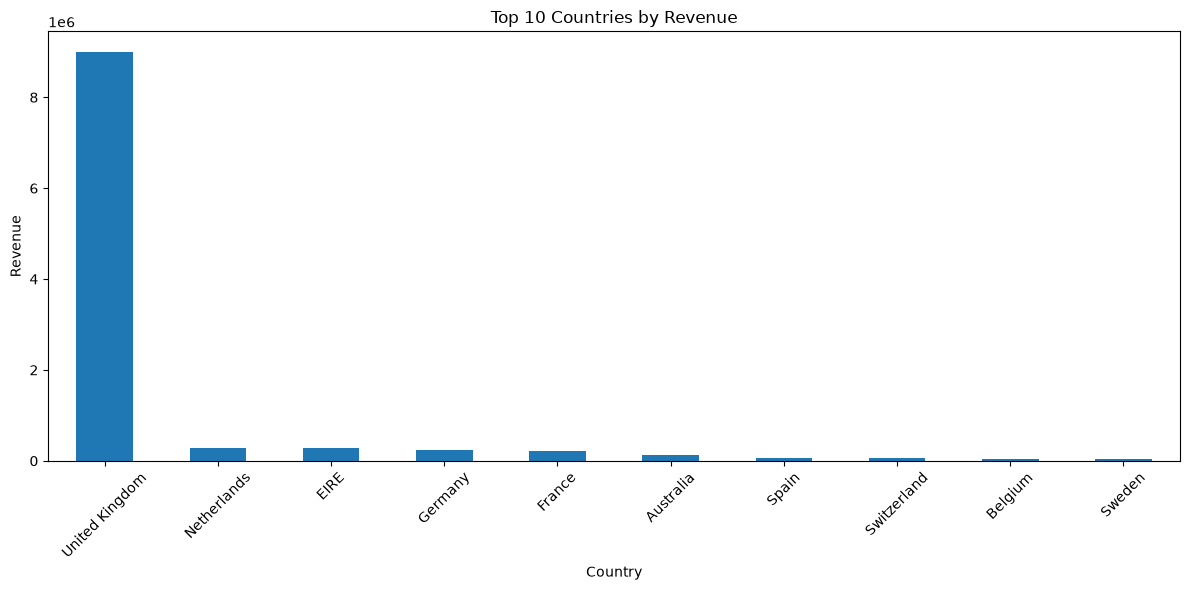

In [35]:
top_countries = country_revenue.head(10)

plt.figure(figsize=(12, 6))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
sales_df["YearMonth"] = sales_df["InvoiceDate"].dt.to_period("M")

In [37]:
monthly_revenue = (
    sales_df.groupby("YearMonth")["Revenue"]
    .sum()
)

In [38]:
monthly_revenue

YearMonth
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637808.330
Freq: M, Name: Revenue, dtype: float64

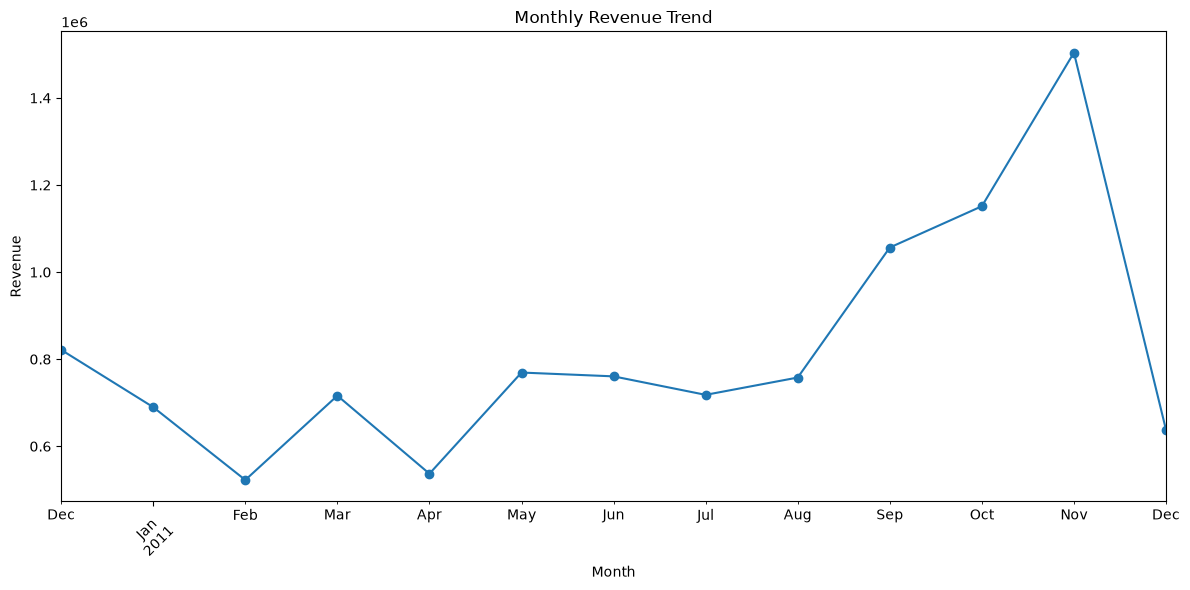

In [39]:
plt.figure(figsize=(12, 6))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [40]:
product_revenue = (
    sales_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78119.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

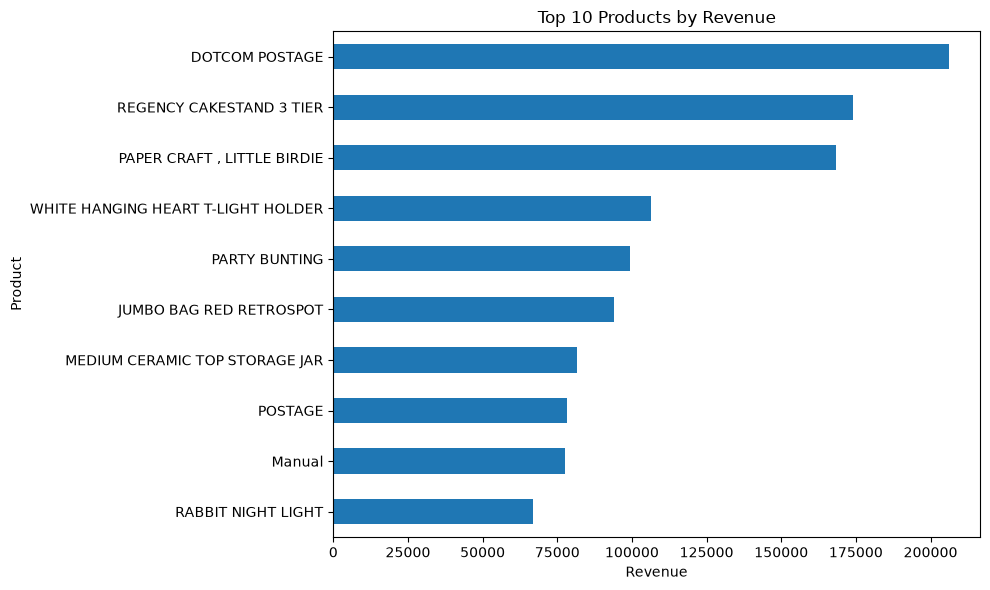

In [41]:
top_products = product_revenue.head(10).sort_values()

plt.figure(figsize=(10, 6))

top_products.plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [42]:
product_quantity = (
    sales_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

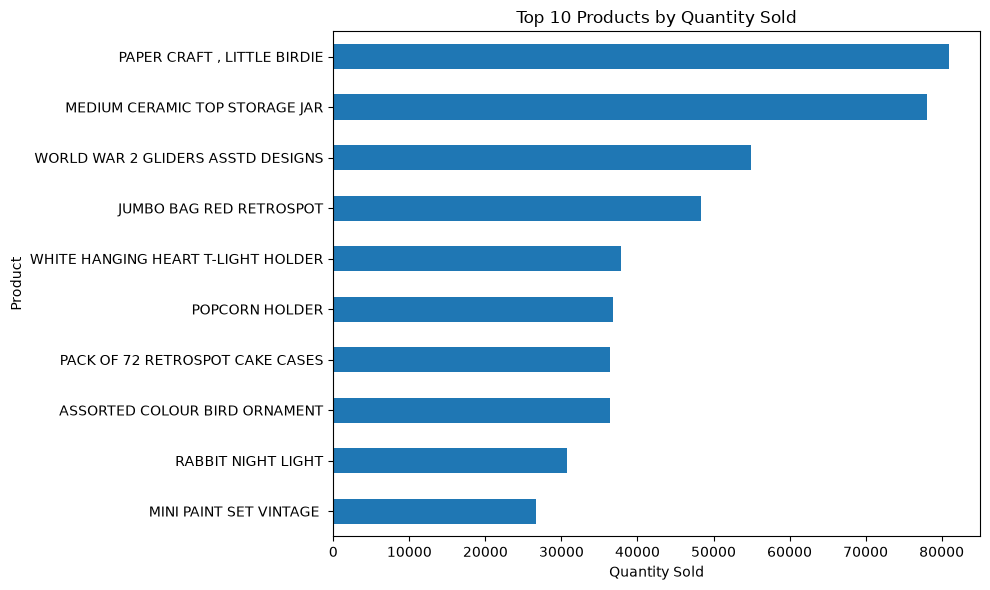

In [43]:
top_quantity_products = product_quantity.head(10).sort_values()

plt.figure(figsize=(10, 6))

top_quantity_products.plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [44]:
sales_df["Description"].nunique()

4026

In [45]:
sales_df["Description"].value_counts().head(20)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2311
JUMBO BAG RED RETROSPOT               2109
REGENCY CAKESTAND 3 TIER              2007
PARTY BUNTING                         1699
LUNCH BAG RED RETROSPOT               1581
ASSORTED COLOUR BIRD ORNAMENT         1476
SET OF 3 CAKE TINS PANTRY DESIGN      1392
PACK OF 72 RETROSPOT CAKE CASES       1352
LUNCH BAG  BLACK SKULL.               1301
NATURAL SLATE HEART CHALKBOARD        1255
JUMBO BAG PINK POLKADOT               1232
HEART OF WICKER SMALL                 1219
JUMBO STORAGE BAG SUKI                1194
PAPER CHAIN KIT 50'S CHRISTMAS        1184
JUMBO SHOPPER VINTAGE RED PAISLEY     1180
JAM MAKING SET PRINTED                1164
LUNCH BAG SPACEBOY DESIGN             1164
LUNCH BAG CARS BLUE                   1162
SPOTTY BUNTING                        1154
JAM MAKING SET WITH JARS              1133
Name: count, dtype: int64

In [46]:
customer_df = sales_df.dropna(subset=["CustomerID"]).copy()

In [47]:
print("Customer analysis rows:", len(customer_df))
print("Unique customers:", customer_df["CustomerID"].nunique())

Customer analysis rows: 392693
Unique customers: 4338


In [48]:
customer_revenue = (
    customer_df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

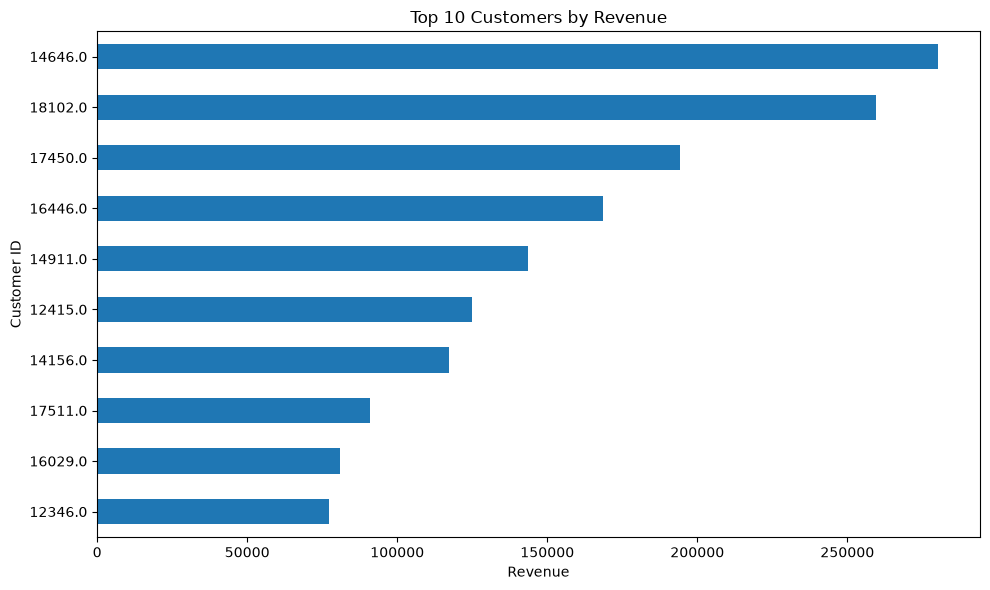

In [49]:
top_customers = customer_revenue.head(10)

plt.figure(figsize=(10, 6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

In [50]:
customer_orders = (
    customer_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

customer_orders.head(10)

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

In [51]:
print("Unique products:", sales_df["Description"].nunique())
print("Unique customers:", customer_df["CustomerID"].nunique())

print("\nTop products:")
print(product_revenue.head(10))

print("\nTop customers:")
print(customer_revenue.head(10))

Unique products: 4026
Unique customers: 4338

Top products:
Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78119.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

Top customers:
CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64


In [52]:
max_date = customer_df["InvoiceDate"].max()

print("Latest transaction:", max_date)

Latest transaction: 2011-12-09 12:50:00


In [53]:
recency = (
    customer_df.groupby("CustomerID")["InvoiceDate"]
    .max()
    .apply(lambda x: (max_date - x).days)
)

In [54]:
recency.head()

CustomerID
12346.0    325
12347.0      1
12348.0     74
12349.0     18
12350.0    309
Name: InvoiceDate, dtype: int64

In [55]:
frequency = (
    customer_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

In [56]:
monetary = (
    customer_df.groupby("CustomerID")["Revenue"]
    .sum()
)

In [57]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

In [58]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [59]:
rfm.shape

(4338, 3)

In [60]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [61]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int) +
    rfm["F_Score"].astype(int) +
    rfm["M_Score"].astype(int)
)

In [62]:
rfm.sort_values("RFM_Score", ascending=False).head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
18245.0,6,7,2567.06,5,5,5,15
18241.0,9,17,2073.09,5,5,5,15
18230.0,8,7,2810.20,5,5,5,15
18229.0,11,20,7276.90,5,5,5,15
18225.0,2,12,5504.96,5,5,5,15
18223.0,4,14,6484.54,5,5,5,15
18219.0,2,10,2069.77,5,5,5,15
18210.0,1,6,2621.38,5,5,5,15
18198.0,3,17,5425.56,5,5,5,15


In [63]:
def segment_customer(row):
    if row["RFM_Score"] >= 13:
        return "VIP Customer"
    elif row["RFM_Score"] >= 10:
        return "Loyal Customer"
    elif row["RFM_Score"] >= 7:
        return "Potential Customer"
    elif row["RFM_Score"] >= 5:
        return "At Risk"
    else:
        return "Lost Customer"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [64]:
rfm["Segment"].value_counts()

Segment
Potential Customer    1088
Loyal Customer        1010
VIP Customer           933
At Risk                763
Lost Customer          544
Name: count, dtype: int64

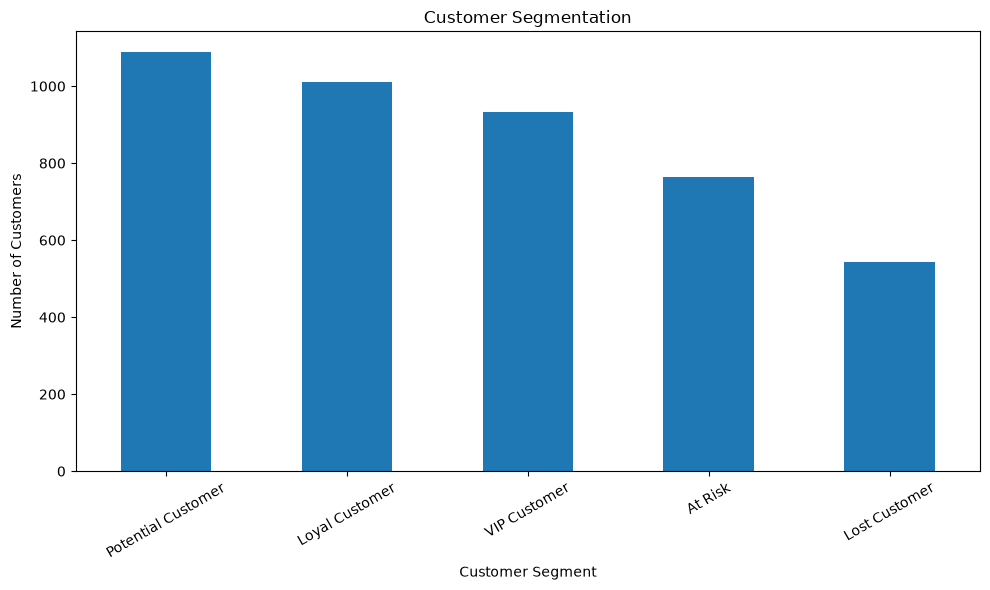

In [65]:
segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(10, 6))

segment_counts.plot(kind="bar")

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [66]:
print(rfm.head())
print("\nSegments:")
print(rfm["Segment"].value_counts())

            Recency  Frequency  Monetary R_Score F_Score M_Score  RFM_Score  \
CustomerID                                                                    
12346.0         325          1  77183.60       1       1       5          7   
12347.0           1          7   4310.00       5       5       5         15   
12348.0          74          4   1797.24       2       4       4         10   
12349.0          18          1   1757.55       4       1       4          9   
12350.0         309          1    334.40       1       1       2          4   

                       Segment  
CustomerID                      
12346.0     Potential Customer  
12347.0           VIP Customer  
12348.0         Loyal Customer  
12349.0     Potential Customer  
12350.0          Lost Customer  

Segments:
Segment
Potential Customer    1088
Loyal Customer        1010
VIP Customer           933
At Risk                763
Lost Customer          544
Name: count, dtype: int64


In [67]:
sql_df = sales_df.copy()

print(sql_df.shape)


(524879, 11)


In [68]:
sql_df = sql_df[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country",
        "Revenue"
    ]
]

In [69]:
sql_df.to_csv(
    "../data/cleaned/ecommerce_cleaned.csv",
    index=False
)

print("Cleaned dataset saved!")

Cleaned dataset saved!


In [70]:
from sqlalchemy import create_engine

In [71]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "root"
password = "Vinay@123"
host = "localhost"
port = 3306
database = "ecommerce_analytics"

encoded_password = quote_plus(password)

engine = create_engine(
    f"mysql+mysqlconnector://{username}:{encoded_password}@{host}:{port}/{database}"
)

print("MySQL engine created!")

MySQL engine created!


In [72]:
with engine.connect() as connection:
    print("Successfully connected to MySQL!")

Successfully connected to MySQL!


In [73]:
print(sql_df.shape)

(524879, 9)


In [74]:
sql_df.to_sql(
    "sales",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=10000,
    method="multi"
)

print("Data successfully loaded into MySQL!")

Data successfully loaded into MySQL!


In [75]:
rfm.to_csv("../data/cleaned/rfm_customers.csv", index=True)

In [76]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,325,1,77183.60,1,1,5,7,Potential Customer
12347.0,1,7,4310.00,5,5,5,15,VIP Customer
12348.0,74,4,1797.24,2,4,4,10,Loyal Customer
12349.0,18,1,1757.55,4,1,4,9,Potential Customer
12350.0,309,1,334.40,1,1,2,4,Lost Customer


In [77]:
rfm.to_csv("../data/cleaned/rfm_customers.csv", index=False)

In [78]:
rfm = rfm.reset_index()

rfm.to_csv("../data/cleaned/rfm_customers.csv", index=False)

print(rfm.columns)

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score',
       'M_Score', 'RFM_Score', 'Segment'],
      dtype='str')
